                # Итоговый notebook для проверки проекта

                В этом ноутбуке собран весь код проекта в линейном и воспроизводимом виде.
                Мы последовательно:

                1. загружаем исторические рыночные данные из репозитория;
                2. строим признаки для прогнозирования волатильности;
                3. обучаем несколько моделей;
                4. сравниваем прогнозную и реальную волатильность на тесте;
                5. считаем торговые метрики, включая `Sharpe` и `Max Drawdown`;
                6. выполняем моделирование волатильности методом Монте-Карло.

                Ноутбук собран специально как единая тетрадка с комментариями к каждому этапу,
                чтобы его можно было проверять без переходов по `.py`-модулям.
                

                ## Этап 0. Подготовка окружения

                Подключаем стандартные библиотеки для аналитики: `numpy`, `pandas`, `matplotlib`.
                Добавлен и небольшой блок для Colab: если ноутбук открыт напрямую из GitHub,
                можно раскомментировать две строки и клонировать репозиторий перед запуском.
                

In [1]:
                # Если ноутбук открыт в Google Colab, раскомментируйте две строки ниже.
                # !git clone https://github.com/FedorKomarovskiy/stock_market_project.git
                # %cd stock_market_project

                from __future__ import annotations

                import math
                from dataclasses import dataclass, field
                from pathlib import Path

                import matplotlib.pyplot as plt
                import numpy as np
                import pandas as pd

                plt.style.use("seaborn-v0_8-whitegrid")
                pd.options.display.float_format = "{:,.6f}".format

                repo_root = Path.cwd().resolve()
                if not (repo_root / "data" / "project_near_hourly_raw.csv").exists() and repo_root.name == "notebooks":
                    repo_root = repo_root.parent

                data_path = repo_root / "data" / "project_near_hourly_raw.csv"
                data_path
                

WindowsPath('C:/Users/admin/Desktop/Проект сток маркет/stock_market_project/data/project_near_hourly_raw.csv')

                ## Этап 1. Загрузка данных

                В репозитории уже есть исторический датасет `project_near_hourly_raw.csv`.
                Это удобно для проверки: ноутбук воспроизводится локально и не зависит от внешнего API.
                

In [2]:
                raw = pd.read_csv(data_path, parse_dates=["timestamp"])
                raw = raw.sort_values("timestamp").reset_index(drop=True)
                raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)

                print(f"Количество строк: {len(raw):,}")
                print(f"Период: {raw['timestamp'].min()} -> {raw['timestamp'].max()}")
                raw.head()
                

Количество строк: 13,739
Период: 2024-08-05 02:00:00+00:00 -> 2026-02-28 23:00:00+00:00


,timestamp,spot_close,spot_volume,futures_close,futures_volume
0,2024-08-05 02:00:00+00:00,3.692000,"220,633.222400",3.691000,"2,264,834.000000"
1,2024-08-05 03:00:00+00:00,3.569600,"64,129.439700",3.564000,"763,117.000000"
2,2024-08-05 04:00:00+00:00,3.547500,"44,515.068400",3.545000,"719,258.000000"
3,2024-08-05 05:00:00+00:00,3.484100,"195,095.894600",3.485000,"2,449,937.000000"
4,2024-08-05 06:00:00+00:00,3.356100,"466,006.958300",3.349000,"10,158,757.000000"


                ## Этап 2. Подготовка признаков и целевой переменной

                Цель этого задания: прогнозировать будущую реализованную волатильность.

                В качестве таргета берём годовую реализованную волатильность на горизонте
                следующих 24 часов:

                - считаем логарифмические доходности;
                - строим rolling-признаки по цене, объёму и базису;
                - для каждого момента времени оцениваем волатильность в следующем окне.
                

In [3]:
                HOURS_IN_YEAR = 24 * 365
                FORECAST_HORIZON = 24

                def rsi(series: pd.Series, window: int = 14) -> pd.Series:
                    delta = series.diff()
                    gain = delta.clip(lower=0.0)
                    loss = -delta.clip(upper=0.0)
                    avg_gain = gain.rolling(window).mean()
                    avg_loss = loss.rolling(window).mean()
                    rs = avg_gain / avg_loss.replace(0.0, np.nan)
                    return 100.0 - (100.0 / (1.0 + rs))

                def future_realized_volatility(returns: pd.Series, horizon: int, annualization: int) -> pd.Series:
                    values = returns.to_numpy(dtype=float)
                    target = np.full(len(values), np.nan, dtype=float)
                    for i in range(len(values) - horizon):
                        window = values[i + 1 : i + 1 + horizon]
                        if np.isnan(window).any():
                            continue
                        target[i] = float(np.std(window, ddof=0) * np.sqrt(annualization))
                    return pd.Series(target, index=returns.index)

                frame = raw.copy()
                frame["basis"] = (frame["futures_close"] - frame["spot_close"]) / frame["spot_close"]
                frame["spot_return"] = np.log(frame["spot_close"]).diff()
                frame["futures_return"] = np.log(frame["futures_close"]).diff()
                frame["basis_return"] = frame["basis"].diff()

                frame["spot_vol_6h"] = frame["spot_return"].rolling(6).std() * np.sqrt(HOURS_IN_YEAR)
                frame["spot_vol_24h"] = frame["spot_return"].rolling(24).std() * np.sqrt(HOURS_IN_YEAR)
                frame["spot_vol_72h"] = frame["spot_return"].rolling(72).std() * np.sqrt(HOURS_IN_YEAR)
                frame["futures_vol_24h"] = frame["futures_return"].rolling(24).std() * np.sqrt(HOURS_IN_YEAR)
                frame["basis_vol_24h"] = frame["basis_return"].rolling(24).std() * np.sqrt(HOURS_IN_YEAR)

                frame["basis_momentum_6h"] = frame["basis"].diff(6)
                frame["basis_zscore_24h"] = (
                    (frame["basis"] - frame["basis"].rolling(24).mean())
                    / frame["basis"].rolling(24).std().replace(0.0, np.nan)
                )
                frame["rolling_corr_24h"] = frame["spot_return"].rolling(24).corr(frame["futures_return"])
                frame["volume_imbalance_24h"] = (
                    (frame["futures_volume"].rolling(24).mean() - frame["spot_volume"].rolling(24).mean())
                    / (frame["futures_volume"].rolling(24).mean() + frame["spot_volume"].rolling(24).mean() + 1e-9)
                )
                frame["spot_rsi_14"] = rsi(frame["spot_close"], 14)
                frame["futures_rsi_14"] = rsi(frame["futures_close"], 14)
                frame["price_change_6h"] = frame["spot_close"].pct_change(6)
                frame["price_change_24h"] = frame["spot_close"].pct_change(24)

                frame["target_future_vol_24h"] = future_realized_volatility(
                    frame["spot_return"],
                    horizon=FORECAST_HORIZON,
                    annualization=HOURS_IN_YEAR,
                )

                feature_columns = [
                    "basis",
                    "spot_return",
                    "futures_return",
                    "basis_return",
                    "spot_vol_6h",
                    "spot_vol_24h",
                    "spot_vol_72h",
                    "futures_vol_24h",
                    "basis_vol_24h",
                    "basis_momentum_6h",
                    "basis_zscore_24h",
                    "rolling_corr_24h",
                    "volume_imbalance_24h",
                    "spot_rsi_14",
                    "futures_rsi_14",
                    "price_change_6h",
                    "price_change_24h",
                ]

                dataset = frame[
                    ["timestamp", "spot_close", "target_future_vol_24h", *feature_columns]
                ].dropna().reset_index(drop=True)
                dataset.head()
                

,timestamp,spot_close,target_future_vol_24h,basis,spot_return,futures_return,basis_return,spot_vol_6h,spot_vol_24h,spot_vol_72h,futures_vol_24h,basis_vol_24h,basis_momentum_6h,basis_zscore_24h,rolling_corr_24h,volume_imbalance_24h,spot_rsi_14,futures_rsi_14,price_change_6h,price_change_24h
0,2024-08-08 02:00:00+00:00,3.718500,0.954166,0.000134,0.013946,0.014081,0.000134,1.834058,1.368197,1.826234,1.361974,0.106101,0.001111,0.677112,0.996986,0.817277,46.046142,45.990180,0.037673,-0.013242
1,2024-08-08 03:00:00+00:00,3.676500,0.917171,-0.000136,-0.011359,-0.011630,-0.000270,1.954956,1.381834,1.791480,1.376259,0.106119,-0.000414,0.341991,0.997043,0.819343,45.726023,45.469256,0.020966,-0.026943
2,2024-08-08 04:00:00+00:00,3.681000,1.041438,-0.000543,0.001223,0.000816,-0.000407,1.954839,1.373221,1.789967,1.367713,0.106377,0.000344,-0.142435,0.996991,0.819508,58.487562,58.677686,0.021025,-0.032563
3,2024-08-08 05:00:00+00:00,3.732000,1.064259,0.000268,0.013760,0.014571,0.000811,1.860636,1.403362,1.783665,1.401172,0.107101,0.001334,0.805873,0.997080,0.814499,62.148430,62.942272,0.046609,-0.018927
4,2024-08-08 06:00:00+00:00,3.728500,1.061142,-0.001207,-0.000938,-0.002414,-0.001475,1.683518,1.388207,1.731425,1.378692,0.100733,-0.001179,-1.112735,0.997370,0.816167,62.477198,63.059701,0.058902,-0.008878


                ## Этап 3. Разделение на train / test без утечки

                Временные ряды нельзя перемешивать случайно. Поэтому делим данные по времени:

                - первые `70%` наблюдений идут в train;
                - последние `30%` оставляем для честной проверки на тесте.
                

In [4]:
                split_index = int(len(dataset) * 0.70)
                train = dataset.iloc[:split_index].copy().reset_index(drop=True)
                test = dataset.iloc[split_index:].copy().reset_index(drop=True)

                print(f"Train rows: {len(train):,}")
                print(f"Test rows:  {len(test):,}")
                print(f"Train period: {train['timestamp'].min()} -> {train['timestamp'].max()}")
                print(f"Test period:  {test['timestamp'].min()} -> {test['timestamp'].max()}")
                

Train rows: 9,548
Test rows:  4,093
Train period: 2024-08-08 02:00:00+00:00 -> 2025-09-10 05:00:00+00:00
Test period:  2025-09-10 06:00:00+00:00 -> 2026-02-27 23:00:00+00:00


                ## Этап 4. Базовая модель и ML-модели

                Для сравнения используем три подхода:

                1. `Naive baseline`: прогноз равен последней наблюдаемой 24-часовой волатильности.
                2. `Linear regression`: простая интерпретируемая линейная модель.
                3. `Gradient boosting`: ансамбль слабых регрессоров на основе деревьев-пней.

                Все реализации записаны прямо в ноутбуке, чтобы решение было автономным.
                

In [5]:
                @dataclass
                class LinearVolatilityModel:
                    means_: np.ndarray | None = None
                    scales_: np.ndarray | None = None
                    weights_: np.ndarray | None = None
                    bias_: float = 0.0
                    feature_names_: list[str] | None = None

                    def fit(self, x: pd.DataFrame, y: pd.Series, ridge: float = 1e-3) -> "LinearVolatilityModel":
                        self.feature_names_ = list(x.columns)
                        x_values = x.to_numpy(dtype=float)
                        y_values = y.to_numpy(dtype=float)

                        self.means_ = x_values.mean(axis=0)
                        self.scales_ = x_values.std(axis=0)
                        self.scales_[self.scales_ == 0.0] = 1.0
                        x_scaled = (x_values - self.means_) / self.scales_

                        x_aug = np.column_stack([np.ones(len(x_scaled)), x_scaled])
                        identity = np.eye(x_aug.shape[1])
                        identity[0, 0] = 0.0

                        beta = np.linalg.solve(x_aug.T @ x_aug + ridge * identity, x_aug.T @ y_values)
                        self.bias_ = float(beta[0])
                        self.weights_ = beta[1:]
                        return self

                    def predict(self, x: pd.DataFrame) -> np.ndarray:
                        x_values = x.to_numpy(dtype=float)
                        x_scaled = (x_values - self.means_) / self.scales_
                        prediction = self.bias_ + x_scaled @ self.weights_
                        return np.clip(prediction, 1e-6, None)

                    def feature_importance(self) -> pd.Series:
                        importance = np.abs(self.weights_)
                        return pd.Series(importance, index=self.feature_names_).sort_values(ascending=False)


                @dataclass
                class RegressionStump:
                    feature_index: int
                    threshold: float
                    left_value: float
                    right_value: float

                    def predict(self, x: np.ndarray) -> np.ndarray:
                        column = x[:, self.feature_index]
                        return np.where(column <= self.threshold, self.left_value, self.right_value)


                @dataclass
                class GradientBoostingRegressorLite:
                    n_estimators: int = 80
                    learning_rate: float = 0.05
                    min_samples_leaf: int = 32
                    quantiles: tuple[float, ...] = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
                    initial_prediction: float = 0.0
                    stumps: list[RegressionStump] = field(default_factory=list)
                    feature_names_: list[str] | None = None

                    def fit(self, x: pd.DataFrame, y: pd.Series) -> "GradientBoostingRegressorLite":
                        self.feature_names_ = list(x.columns)
                        features = x.to_numpy(dtype=float)
                        target = y.to_numpy(dtype=float)
                        self.initial_prediction = float(np.mean(target))
                        current_pred = np.full(len(target), self.initial_prediction, dtype=float)
                        self.stumps = []

                        for _ in range(self.n_estimators):
                            residual = target - current_pred
                            stump = self._fit_best_stump(features, residual)
                            if stump is None:
                                break
                            current_pred += self.learning_rate * stump.predict(features)
                            self.stumps.append(stump)
                        return self

                    def predict(self, x: pd.DataFrame) -> np.ndarray:
                        features = x.to_numpy(dtype=float)
                        pred = np.full(len(features), self.initial_prediction, dtype=float)
                        for stump in self.stumps:
                            pred += self.learning_rate * stump.predict(features)
                        return np.clip(pred, 1e-6, None)

                    def _fit_best_stump(self, x: np.ndarray, residual: np.ndarray) -> RegressionStump | None:
                        best_stump = None
                        best_loss = float("inf")
                        for feature_index in range(x.shape[1]):
                            column = x[:, feature_index]
                            thresholds = sorted(set(float(v) for v in np.quantile(column, self.quantiles)))
                            for threshold in thresholds:
                                left_mask = column <= threshold
                                right_mask = ~left_mask
                                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                                    continue
                                left_value = float(np.mean(residual[left_mask]))
                                right_value = float(np.mean(residual[right_mask]))
                                loss = float(
                                    np.sum((residual[left_mask] - left_value) ** 2)
                                    + np.sum((residual[right_mask] - right_value) ** 2)
                                )
                                if loss < best_loss:
                                    best_loss = loss
                                    best_stump = RegressionStump(
                                        feature_index=feature_index,
                                        threshold=float(threshold),
                                        left_value=left_value,
                                        right_value=right_value,
                                    )
                        return best_stump

                    def feature_importance(self) -> pd.Series:
                        if not self.stumps:
                            return pd.Series(dtype=float)
                        counts = pd.Series(0.0, index=self.feature_names_)
                        for stump in self.stumps:
                            counts.iloc[stump.feature_index] += abs(stump.left_value - stump.right_value)
                        return counts.sort_values(ascending=False)


                def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
                    actual = y_true.to_numpy(dtype=float)
                    pred = np.asarray(y_pred, dtype=float)
                    residual = actual - pred
                    mae = float(np.mean(np.abs(residual)))
                    rmse = float(np.sqrt(np.mean(residual ** 2)))
                    mape = float(np.mean(np.abs(residual) / np.clip(np.abs(actual), 1e-9, None)))
                    ss_res = float(np.sum(residual ** 2))
                    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
                    r2 = 0.0 if ss_tot <= 0.0 else float(1.0 - ss_res / ss_tot)
                    corr = float(np.corrcoef(actual, pred)[0, 1]) if len(actual) > 1 else 0.0
                    if math.isnan(corr):
                        corr = 0.0
                    return {
                        "mae": mae,
                        "rmse": rmse,
                        "mape": mape,
                        "r2": r2,
                        "correlation": corr,
                    }
                

In [6]:
                x_train = train[feature_columns]
                y_train = train["target_future_vol_24h"]
                x_test = test[feature_columns]
                y_test = test["target_future_vol_24h"]

                linear_model = LinearVolatilityModel().fit(x_train, y_train)
                gb_model = GradientBoostingRegressorLite().fit(x_train, y_train)

                train_naive_pred = train["spot_vol_24h"].to_numpy()
                test_naive_pred = test["spot_vol_24h"].to_numpy()
                train_linear_pred = linear_model.predict(x_train)
                test_linear_pred = linear_model.predict(x_test)
                train_gb_pred = gb_model.predict(x_train)
                test_gb_pred = gb_model.predict(x_test)

                forecast_metrics = pd.DataFrame(
                    [
                        {"model": "naive_vol_24h", **regression_metrics(y_test, test_naive_pred)},
                        {"model": "linear_regression", **regression_metrics(y_test, test_linear_pred)},
                        {"model": "gradient_boosting_lite", **regression_metrics(y_test, test_gb_pred)},
                    ]
                ).sort_values(["rmse", "mae"]).reset_index(drop=True)

                forecast_metrics
                

,model,mae,rmse,mape,r2,correlation
0,gradient_boosting_lite,0.272208,0.390394,0.354908,0.155996,0.412270
1,linear_regression,0.266351,0.391361,0.334684,0.151812,0.399708
2,naive_vol_24h,0.321364,0.467484,0.383551,-0.210238,0.408633


                ## Этап 5. Графики прогнозной и реальной волатильности

                На этом этапе сравниваем прогнозную и фактическую реализованную волатильность
                на тестовом участке и дополнительно смотрим scatter-графики `факт vs прогноз`.
                

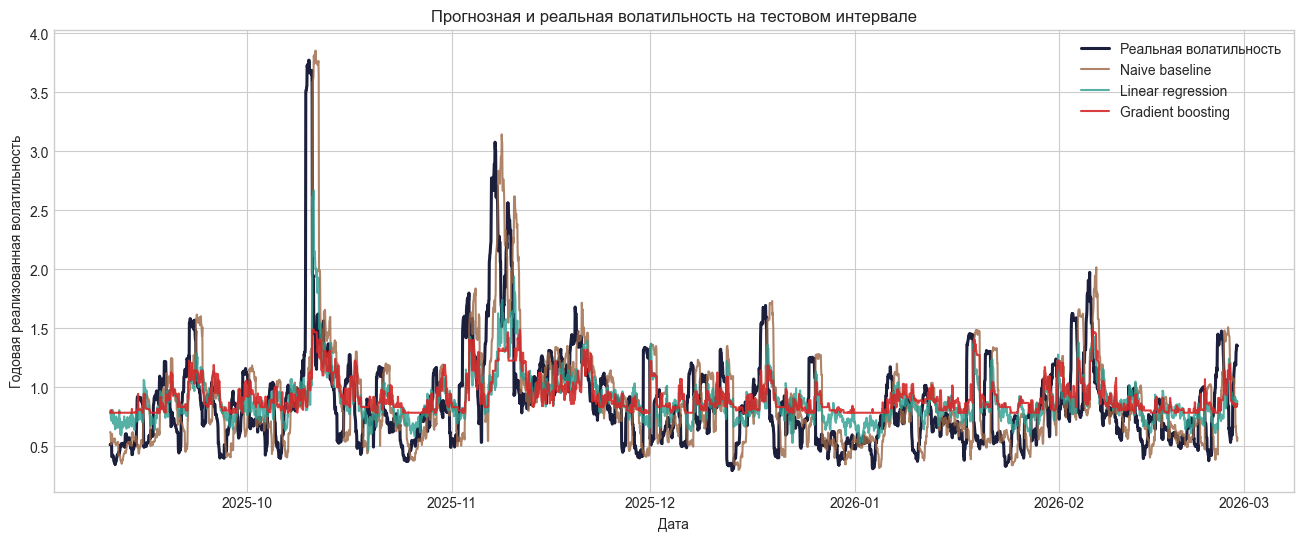

In [7]:
                comparison = test[["timestamp", "target_future_vol_24h"]].copy()
                comparison["naive_vol_24h"] = test_naive_pred
                comparison["linear_regression"] = test_linear_pred
                comparison["gradient_boosting_lite"] = test_gb_pred

                fig, ax = plt.subplots(figsize=(16, 6))
                ax.plot(
                    comparison["timestamp"],
                    comparison["target_future_vol_24h"],
                    label="Реальная волатильность",
                    linewidth=2.2,
                    color="#1b1f3b",
                )
                ax.plot(comparison["timestamp"], comparison["naive_vol_24h"], label="Naive baseline", alpha=0.80, color="#9c6644")
                ax.plot(comparison["timestamp"], comparison["linear_regression"], label="Linear regression", alpha=0.80, color="#2a9d8f")
                ax.plot(comparison["timestamp"], comparison["gradient_boosting_lite"], label="Gradient boosting", alpha=0.90, color="#d62828")
                ax.set_title("Прогнозная и реальная волатильность на тестовом интервале")
                ax.set_xlabel("Дата")
                ax.set_ylabel("Годовая реализованная волатильность")
                ax.legend()
                plt.show()
                

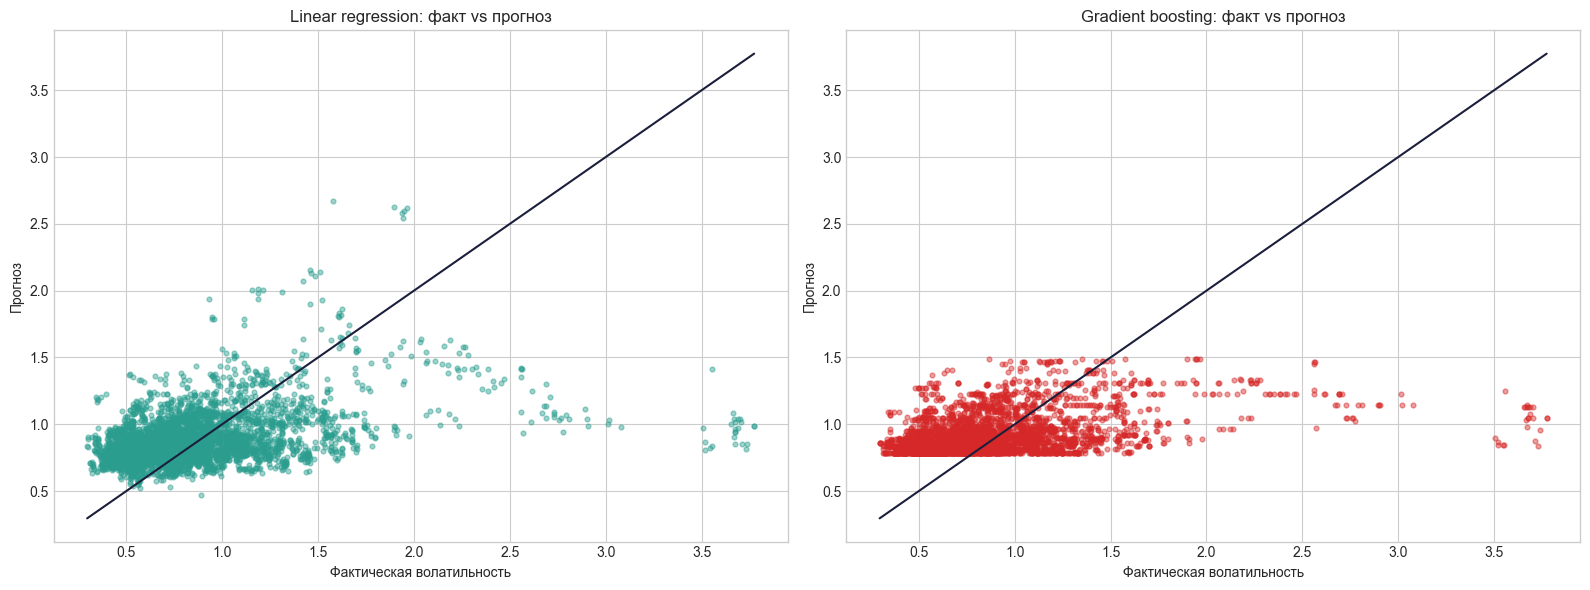

In [8]:
                fig, axes = plt.subplots(1, 2, figsize=(16, 6))

                axes[0].scatter(y_test, test_linear_pred, s=12, alpha=0.45, color="#2a9d8f")
                axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#1b1f3b", linewidth=1.5)
                axes[0].set_title("Linear regression: факт vs прогноз")
                axes[0].set_xlabel("Фактическая волатильность")
                axes[0].set_ylabel("Прогноз")

                axes[1].scatter(y_test, test_gb_pred, s=12, alpha=0.45, color="#d62828")
                axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#1b1f3b", linewidth=1.5)
                axes[1].set_title("Gradient boosting: факт vs прогноз")
                axes[1].set_xlabel("Фактическая волатильность")
                axes[1].set_ylabel("Прогноз")

                plt.tight_layout()
                plt.show()
                

                ## Этап 6. Визуализации моделей

                Здесь показываем, какие признаки сильнее всего влияют на прогноз:

                - у линейной модели смотрим модуль коэффициентов;
                - у бустинга считаем суммарный вклад признаков через частоту и силу выбранных пней.
                

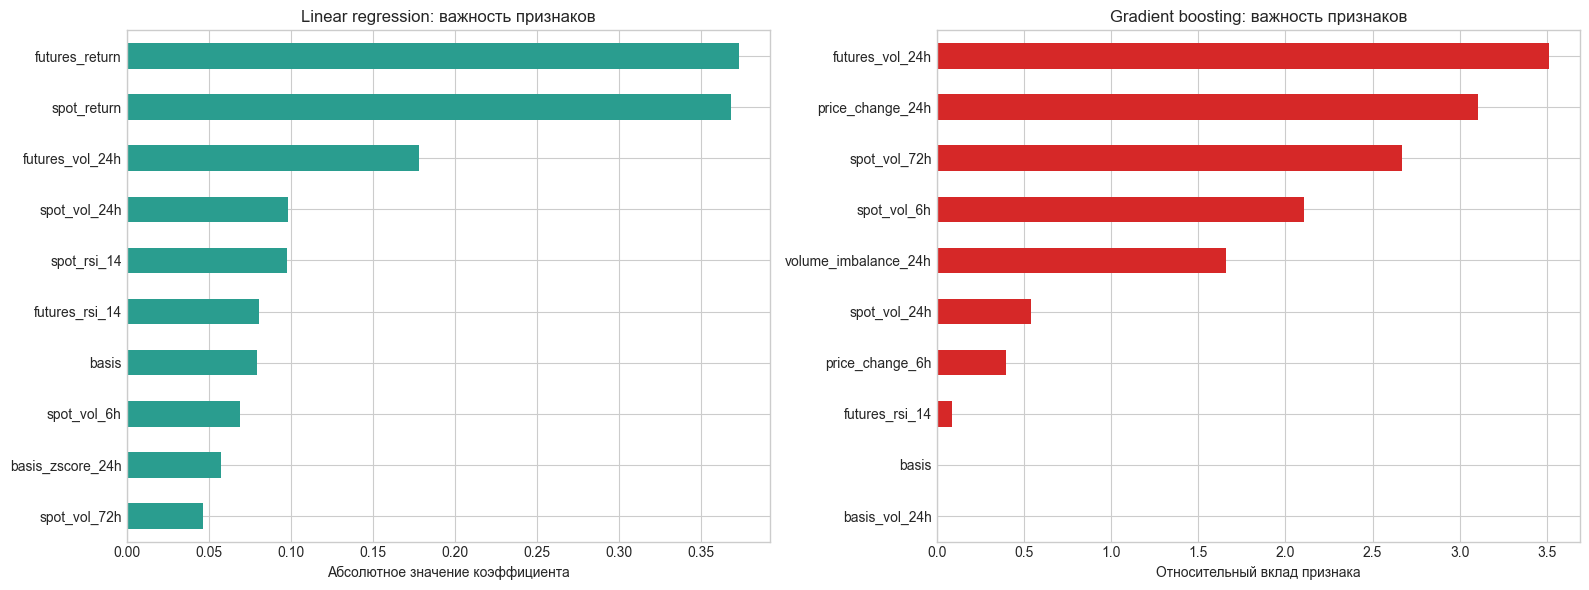

In [9]:
                linear_importance = linear_model.feature_importance().head(10)
                gb_importance = gb_model.feature_importance().head(10)

                fig, axes = plt.subplots(1, 2, figsize=(16, 6))

                linear_importance.sort_values().plot(kind="barh", ax=axes[0], color="#2a9d8f")
                axes[0].set_title("Linear regression: важность признаков")
                axes[0].set_xlabel("Абсолютное значение коэффициента")

                gb_importance.sort_values().plot(kind="barh", ax=axes[1], color="#d62828")
                axes[1].set_title("Gradient boosting: важность признаков")
                axes[1].set_xlabel("Относительный вклад признака")

                plt.tight_layout()
                plt.show()
                

                ## Этап 7. Простая торговая логика на основе прогноза волатильности

                Чтобы посчитать `Sharpe` и `Max Drawdown`, превращаем прогноз волатильности
                в риск-фильтр:

                - если модель ожидает спокойный режим, стратегия держит актив;
                - если прогнозируется высокая волатильность, стратегия уходит в кэш.

                Порог подбирается только на train по `Sharpe`, а затем переносится на test.
                

In [10]:
                def annualized_sharpe(returns: pd.Series, periods_per_year: int = HOURS_IN_YEAR) -> float:
                    values = returns.astype(float)
                    std = float(values.std(ddof=0))
                    if std <= 0.0:
                        return 0.0
                    return float((values.mean() / std) * np.sqrt(periods_per_year))

                def max_drawdown(equity: pd.Series) -> float:
                    running_peak = equity.cummax()
                    drawdown = equity / running_peak - 1.0
                    return float(drawdown.min())

                def strategy_metrics(returns: pd.Series, strategy_name: str) -> dict[str, float | str]:
                    equity = (1.0 + returns.fillna(0.0)).cumprod()
                    total_return = float(equity.iloc[-1] - 1.0)
                    return {
                        "strategy": strategy_name,
                        "total_return": total_return,
                        "sharpe": annualized_sharpe(returns),
                        "max_drawdown": max_drawdown(equity),
                        "annualized_volatility": float(returns.std(ddof=0) * np.sqrt(HOURS_IN_YEAR)),
                    }

                def best_vol_threshold(train_pred: np.ndarray, next_returns: pd.Series) -> float:
                    candidate_thresholds = np.quantile(train_pred, [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
                    best_threshold = float(candidate_thresholds[0])
                    best_sharpe = -np.inf
                    for threshold in candidate_thresholds:
                        signal = (train_pred <= threshold).astype(float)
                        strategy_ret = signal * next_returns.to_numpy(dtype=float)
                        sharpe = annualized_sharpe(pd.Series(strategy_ret))
                        if sharpe > best_sharpe:
                            best_sharpe = sharpe
                            best_threshold = float(threshold)
                    return best_threshold

                train_next_return = train["spot_return"].shift(-1).fillna(0.0)
                test_next_return = test["spot_return"].shift(-1).fillna(0.0)

                naive_threshold = best_vol_threshold(train_naive_pred, train_next_return)
                linear_threshold = best_vol_threshold(train_linear_pred, train_next_return)
                gb_threshold = best_vol_threshold(train_gb_pred, train_next_return)

                strategy_frame = test[["timestamp"]].copy()
                strategy_frame["buy_and_hold"] = test_next_return.to_numpy()
                strategy_frame["naive_strategy"] = (test_naive_pred <= naive_threshold).astype(float) * test_next_return.to_numpy()
                strategy_frame["linear_strategy"] = (test_linear_pred <= linear_threshold).astype(float) * test_next_return.to_numpy()
                strategy_frame["gradient_boosting_strategy"] = (test_gb_pred <= gb_threshold).astype(float) * test_next_return.to_numpy()

                trade_metrics = pd.DataFrame(
                    [
                        strategy_metrics(strategy_frame["buy_and_hold"], "buy_and_hold"),
                        strategy_metrics(strategy_frame["naive_strategy"], "naive_vol_filter"),
                        strategy_metrics(strategy_frame["linear_strategy"], "linear_vol_filter"),
                        strategy_metrics(strategy_frame["gradient_boosting_strategy"], "gradient_boosting_vol_filter"),
                    ]
                ).sort_values("sharpe", ascending=False).reset_index(drop=True)

                trade_metrics
                

,strategy,total_return,sharpe,max_drawdown,annualized_volatility
0,naive_vol_filter,0.033954,0.378998,-0.333645,0.400561
1,linear_vol_filter,-0.213975,-0.794505,-0.479355,0.494513
2,gradient_boosting_vol_filter,-0.271814,-0.904368,-0.436517,0.570584
3,buy_and_hold,-0.691217,-2.035917,-0.767769,0.991841


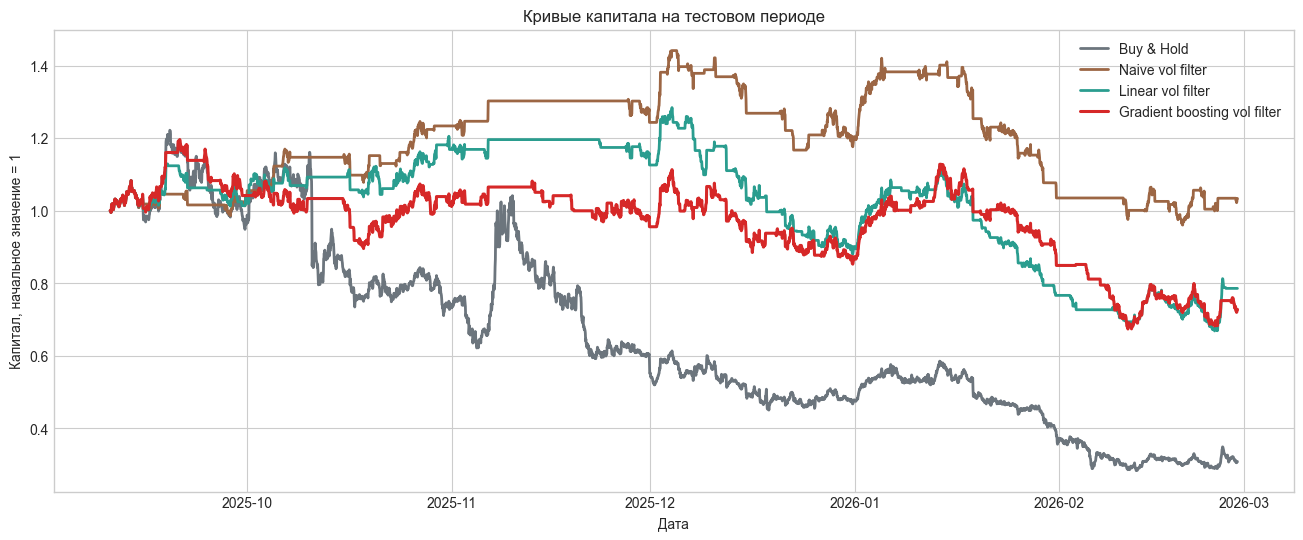

In [11]:
                equity_curves = pd.DataFrame({"timestamp": strategy_frame["timestamp"]})
                for column in ["buy_and_hold", "naive_strategy", "linear_strategy", "gradient_boosting_strategy"]:
                    equity_curves[column] = (1.0 + strategy_frame[column].fillna(0.0)).cumprod()

                fig, ax = plt.subplots(figsize=(16, 6))
                ax.plot(equity_curves["timestamp"], equity_curves["buy_and_hold"], label="Buy & Hold", linewidth=2.0, color="#6c757d")
                ax.plot(equity_curves["timestamp"], equity_curves["naive_strategy"], label="Naive vol filter", linewidth=2.0, color="#9c6644")
                ax.plot(equity_curves["timestamp"], equity_curves["linear_strategy"], label="Linear vol filter", linewidth=2.0, color="#2a9d8f")
                ax.plot(equity_curves["timestamp"], equity_curves["gradient_boosting_strategy"], label="Gradient boosting vol filter", linewidth=2.2, color="#d62828")
                ax.set_title("Кривые капитала на тестовом периоде")
                ax.set_xlabel("Дата")
                ax.set_ylabel("Капитал, начальное значение = 1")
                ax.legend()
                plt.show()
                

                ## Этап 8. Моделирование волатильности методом Монте-Карло

                Финальный блок, который отдельно требовался в задании.

                Используем лучшую модель по `RMSE`, берём её последнюю оценку волатильности
                и строим распределение возможных ценовых траекторий на следующие 24 часа.
                Для простоты применяется геометрическое броуновское движение:

                - drift оцениваем по среднему часовому лог-доходу за последние 30 суток;
                - sigma берём из прогноза волатильности и переводим в часовую шкалу;
                - дальше симулируем множество траекторий и показываем веер сценариев.
                

In [12]:
                best_model_name = forecast_metrics.iloc[0]["model"]
                prediction_map = {
                    "naive_vol_24h": test_naive_pred,
                    "linear_regression": test_linear_pred,
                    "gradient_boosting_lite": test_gb_pred,
                }
                best_predictions = prediction_map[best_model_name]

                latest_price = float(test["spot_close"].iloc[-1])
                latest_predicted_vol = float(best_predictions[-1])
                recent_returns = dataset["spot_return"].tail(24 * 30)
                hourly_drift = float(recent_returns.mean())
                hourly_sigma = float(latest_predicted_vol / np.sqrt(HOURS_IN_YEAR))

                rng = np.random.default_rng(42)
                n_paths = 1000
                n_steps = 24
                price_paths = np.zeros((n_paths, n_steps + 1), dtype=float)
                price_paths[:, 0] = latest_price

                for step in range(1, n_steps + 1):
                    shocks = rng.normal(loc=0.0, scale=1.0, size=n_paths)
                    growth = (hourly_drift - 0.5 * hourly_sigma ** 2) + hourly_sigma * shocks
                    price_paths[:, step] = price_paths[:, step - 1] * np.exp(growth)

                percentiles = {
                    "p10": np.percentile(price_paths, 10, axis=0),
                    "p50": np.percentile(price_paths, 50, axis=0),
                    "p90": np.percentile(price_paths, 90, axis=0),
                }

                simulation_summary = pd.DataFrame(
                    {
                        "metric": [
                            "best_model",
                            "latest_price",
                            "predicted_annualized_volatility",
                            "hourly_sigma",
                            "median_terminal_price",
                            "p10_terminal_price",
                            "p90_terminal_price",
                        ],
                        "value": [
                            best_model_name,
                            latest_price,
                            latest_predicted_vol,
                            hourly_sigma,
                            float(percentiles["p50"][-1]),
                            float(percentiles["p10"][-1]),
                            float(percentiles["p90"][-1]),
                        ],
                    }
                )

                simulation_summary
                

,metric,value
0,best_model,gradient_boosting_lite
1,latest_price,1.093800
2,predicted_annualized_volatility,0.860254
3,hourly_sigma,0.009191
4,median_terminal_price,1.079410
5,p10_terminal_price,1.025058
6,p90_terminal_price,1.144738


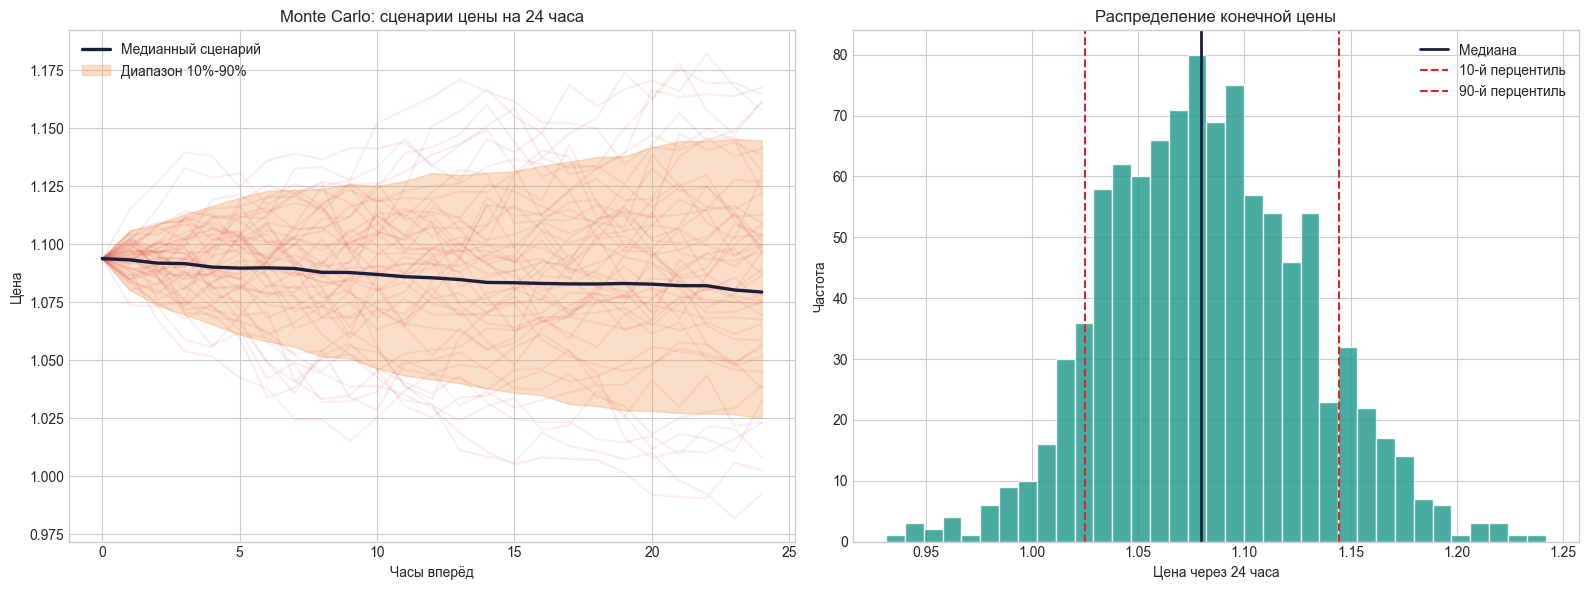

In [13]:
                horizon_axis = np.arange(n_steps + 1)

                fig, axes = plt.subplots(1, 2, figsize=(16, 6))

                for path in price_paths[:50]:
                    axes[0].plot(horizon_axis, path, color="#d62828", alpha=0.08)
                axes[0].plot(horizon_axis, percentiles["p50"], color="#1b1f3b", linewidth=2.4, label="Медианный сценарий")
                axes[0].fill_between(horizon_axis, percentiles["p10"], percentiles["p90"], color="#f4a261", alpha=0.35, label="Диапазон 10%-90%")
                axes[0].set_title("Monte Carlo: сценарии цены на 24 часа")
                axes[0].set_xlabel("Часы вперёд")
                axes[0].set_ylabel("Цена")
                axes[0].legend()

                axes[1].hist(price_paths[:, -1], bins=35, color="#2a9d8f", alpha=0.85, edgecolor="white")
                axes[1].axvline(percentiles["p50"][-1], color="#1b1f3b", linewidth=2, label="Медиана")
                axes[1].axvline(percentiles["p10"][-1], color="#d62828", linewidth=1.5, linestyle="--", label="10-й перцентиль")
                axes[1].axvline(percentiles["p90"][-1], color="#d62828", linewidth=1.5, linestyle="--", label="90-й перцентиль")
                axes[1].set_title("Распределение конечной цены")
                axes[1].set_xlabel("Цена через 24 часа")
                axes[1].set_ylabel("Частота")
                axes[1].legend()

                plt.tight_layout()
                plt.show()
                

                ## Этап 9. Финальный вывод

                В результате получаем notebook, который закрывает замечания проверяющего:

                - всё решение собрано в одном Jupyter Notebook;
                - каждый этап снабжён комментариями;
                - есть графики реальной и прогнозной волатильности;
                - есть визуализации моделей;
                - есть таблицы с метриками, включая `Sharpe` и `Max Drawdown`;
                - есть отдельный блок моделирования волатильности методом Монте-Карло.

                Такой формат удобно проверять и запускать как локально, так и в Colab.
                